In [15]:
!git clone https://github.com/Nrrahat/dt_assingment.git

fatal: destination path 'dt_assingment' already exists and is not an empty directory.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv(
    "/content/dt_assingment/dataset/Iris.csv"
)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
# Check missing values
print(df.isnull().sum())

# Split features/target
X = df.drop("Species", axis=1)
y = df["Species"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [19]:
X_train_2d = X_train.iloc[:, :2]
X_test_2d = X_test.iloc[:, :2]

In [20]:
cart = GridSearchCV(
    DecisionTreeClassifier(criterion="gini"),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6],
        "min_samples_split": [2, 5, 10]
    },
    cv=5
)

cart.fit(X_train_2d, y_train)
best_cart = cart.best_estimator_
print(cart.best_params_)

{'max_depth': 2, 'min_samples_split': 2}


In [21]:
id3 = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy"),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6],
        "min_samples_split": [2, 5, 10]
    },
    cv=5
)

id3.fit(X_train_2d, y_train)
best_id3 = id3.best_estimator_
print(id3.best_params_)

{'max_depth': 2, 'min_samples_split': 2}


In [22]:
cart_pred = best_cart.predict(X_test_2d)
id3_pred = best_id3.predict(X_test_2d)

In [23]:
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)   # NO pandas here
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

    plt.title(title)

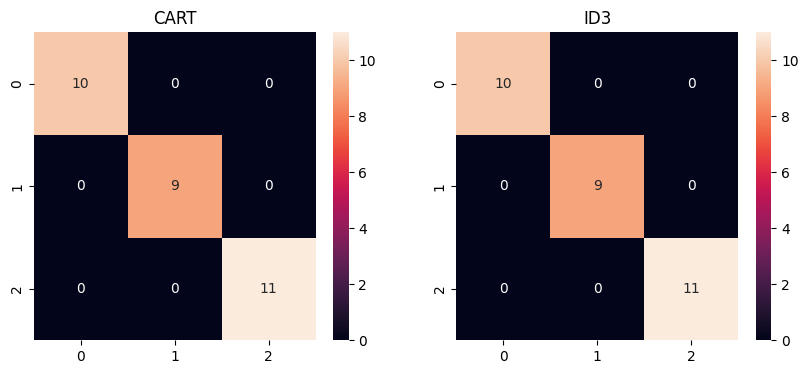

In [24]:
import seaborn as sns

fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, cart_pred), annot=True, ax=ax[0])
ax[0].set_title("CART")

sns.heatmap(confusion_matrix(y_test, id3_pred), annot=True, ax=ax[1])
ax[1].set_title("ID3")

plt.show()

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize output
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = 3

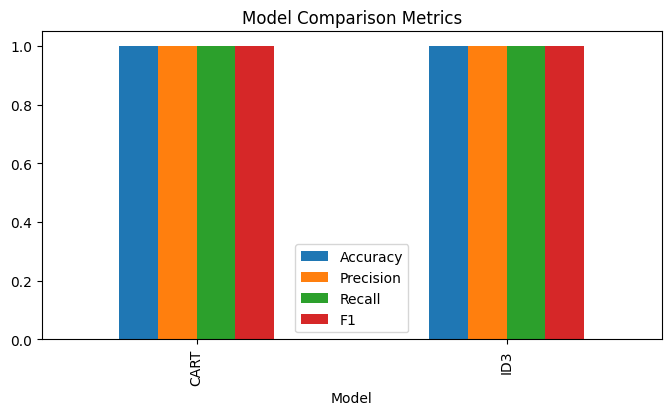

In [27]:
metrics = {
    "Model": ["CART", "ID3"],
    "Accuracy": [
        accuracy_score(y_test, cart_pred),
        accuracy_score(y_test, id3_pred)
    ],
    "Precision": [
        precision_score(y_test, cart_pred, average="macro"),
        precision_score(y_test, id3_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, cart_pred, average="macro"),
        recall_score(y_test, id3_pred, average="macro")
    ],
    "F1": [
        f1_score(y_test, cart_pred, average="macro"),
        f1_score(y_test, id3_pred, average="macro")
    ]
}

dfm = pd.DataFrame(metrics)

dfm.set_index("Model").plot(kind="bar", figsize=(8,4))
plt.title("Model Comparison Metrics")
plt.show()

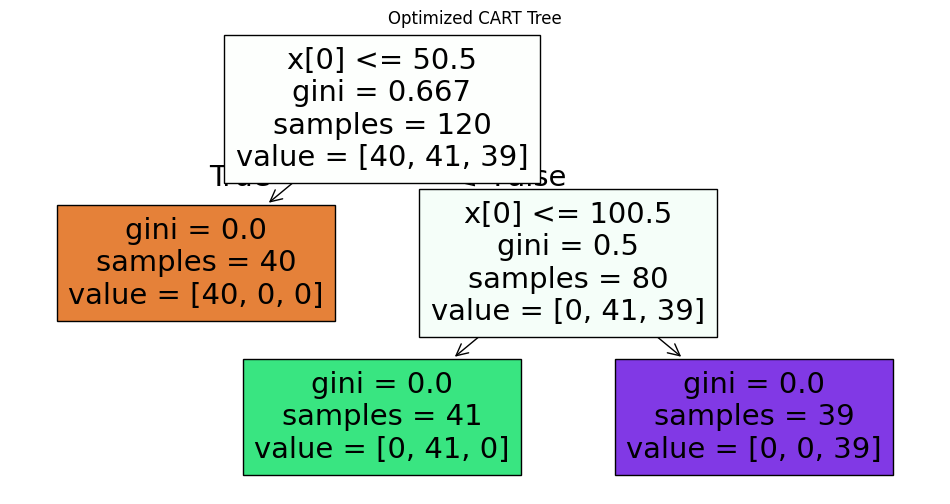

In [28]:
plt.figure(figsize=(12,6))
plot_tree(best_cart, filled=True)
plt.title("Optimized CART Tree")
plt.show()